# Expirements for the Image Sticthing App

In [1]:
import cv2 
import numpy as np
import pandas as pd
from itertools import compress
import matplotlib.pyplot as plt
import main
import utils.file_utils as file_utils
import models

## Critical Steps
1. Get All Features Into a Table

In [2]:
img_paths = file_utils.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image-stitching/datasets/example-data/myself")
orb = cv2.ORB_create()

img_id_bounds = np.array([0], dtype=np.uint32)  # indicated at which ID an image starts/end
N = 0
des = np.empty((0,32), dtype=np.uint8) # data type is crucial!
img_ids = np.empty((0))
kps = ()

for img_id, img_path in enumerate(img_paths): 
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    kp_new, des_new = orb.detectAndCompute(img, None)  # type: ignore
    des = np.vstack((des, des_new))
    kps +=  kp_new
    N_new = len(des_new)
    N += N_new
    img_id_bounds = np.append(img_id_bounds, N)
    img_ids_new = np.full((N_new), img_id+1)
    img_ids = np.concatenate((img_ids, img_ids_new), axis=0)

In [3]:
len(kp_new)

500

In [4]:
type(kps), type(kps[0])

(tuple, cv2.KeyPoint)

In [5]:
len(kps)

5500

In [6]:
# descriptor IDs from at 0 until 499, belong to Image ID 1
# descriptor IDs from at 500 until 999, belong to Image ID 2
# ...
# descriptor IDs from at 1500 until 1999, belong to Image ID 4
img_id_bounds

array([   0,  500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
       5500])

In [7]:
img_ids

array([ 1.,  1.,  1., ..., 11., 11., 11.], shape=(5500,))

In [8]:
des

array([[105, 149,  87, ..., 114, 227,  51],
       [226, 167,  69, ..., 130, 198,  60],
       [118, 166, 193, ..., 131, 134, 114],
       ...,
       [186, 186, 100, ...,   4, 126, 223],
       [ 42, 237, 148, ...,  92, 189, 142],
       [  1, 141,  31, ..., 192, 129, 169]], shape=(5500, 32), dtype=uint8)

In [9]:
matching_df = pd.DataFrame(
    {"Descriptor" : list(des),
     "ImgId" : img_ids})
convert_dict ={"ImgId": np.uint8}  # dont expect more than 2^8 / 255 images
matching_df = matching_df.astype(convert_dict)
print(matching_df.dtypes)
print("Descriptor dtype:", type(matching_df["Descriptor"].iloc[0]), matching_df["Descriptor"].iloc[0].dtype)
matching_df.head()

Descriptor    object
ImgId          uint8
dtype: object
Descriptor dtype: <class 'numpy.ndarray'> uint8


,Descriptor,ImgId
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1


In [10]:
x = np.stack(list(matching_df["Descriptor"]))
x

array([[105, 149,  87, ..., 114, 227,  51],
       [226, 167,  69, ..., 130, 198,  60],
       [118, 166, 193, ..., 131, 134, 114],
       ...,
       [186, 186, 100, ...,   4, 126, 223],
       [ 42, 237, 148, ...,  92, 189, 142],
       [  1, 141,  31, ..., 192, 129, 169]], shape=(5500, 32), dtype=uint8)

In [11]:
# Define FLANN parameters and match descriptors
# from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12,     # 20
                   multi_probe_level = 1) #2
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(x,x, k=5)

# 2nd Method, Not Working
# FLANN_INDEX_KDTREE = 0
# index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
# search_params = dict(checks=50)
# flann = cv2.FlannBasedMatcher(index_params, search_params)
# matches = flann.knnMatch(des, des, k=2)

In [12]:
# we see that the 1st match, is always matched the result of the keypoint being matched with itself
for M in matches[111:123]:
    m = M[0]
    print(m.trainIdx, m.queryIdx)

111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122


In [13]:
type(matches), type(matches[0]), type(matches[0][0])

(tuple, tuple, cv2.DMatch)

In [14]:
# so remove the 1st match for all of them
matches1 = tuple((m[1:]) for m in matches)

In [15]:
matches_list, matched_col = list(), list()

for i, m_tuple in enumerate(matches):
    m_list = list(m_tuple[1:])
    matches_list.append(m_list)
    matched_col.append(np.array([m.trainIdx for m in m_list]))

In [16]:
type(matches_list), type(matches_list[0]), type(matches), type(matches)

(list, list, tuple, tuple)

In [17]:
matched_col[0:5]

[array([5073, 3547, 3138, 5189]),
 array([  2, 145, 690, 684]),
 array([   1, 5041, 3302, 3213]),
 array([  85, 3663, 3450, 2088]),
 array([5075, 5197, 4038, 1502])]

In [18]:
matching_df['Matched_Ids'] = matched_col

In [19]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[2, 145, 690, 684]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[1, 5041, 3302, 3213]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[85, 3663, 3450, 2088]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 5197, 4038, 1502]"


In [20]:
# convert matched descriptor ids to img ids 
def descriptor_id_to_img_id(id,bounds) -> int:
    """
    Get the associated Image ID for the given Descriptor ID, using the given bounds. 
    Returns:
        int: in range from 1 to length of bounds
    """
    return np.searchsorted(bounds, id, side='right')

def matched_ids_to_img_ids(row, bounds):
    matched_ids = row['Matched_Ids']
    img_ids = [descriptor_id_to_img_id(id, bounds) for id in matched_ids]
    return np.array(img_ids)

matching_df['Matched_ImgIds'] = matching_df.apply(matched_ids_to_img_ids, 
                                                  axis=1, 
                                                  args=(img_id_bounds,))

In [21]:
for m in matches_list[0:5]:
    print(len(m))

4
4
4
4
4


In [22]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]","[11, 8, 7, 11]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[2, 145, 690, 684]","[1, 1, 2, 2]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[1, 5041, 3302, 3213]","[1, 11, 7, 7]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[85, 3663, 3450, 2088]","[1, 8, 7, 5]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 5197, 4038, 1502]","[11, 11, 9, 4]"


In [23]:
# remove Matched Ids of descriptors that belong to the same image
def remove_invalid_matches(row, matches_list: list) -> pd.Series:
    """
    Removes Ids from Matched_Ids that are the are from the same Image (ImgId).
    Also modifies the list matches_list passed as an argument.
    Args:
        row: a row from a pandas dataframe

    Returns:
        series: a series for containing the updated Matched_Ids and Matched_ImgIds, with invalid values removed.
    """
    index, matched_ids, img_ids, imgId = int(row.name), row['Matched_Ids'], row['Matched_ImgIds'], row['ImgId'] 
    indeces_to_remove = np.where(img_ids == imgId)
    # create mask to remove values
    mask = np.ones(len(matched_ids), dtype=bool)
    mask[indeces_to_remove] = False
    matched_ids = matched_ids[mask,...]
    img_ids = img_ids[mask,...]
    matches_list[index] = list(compress(matches_list[index], mask))
    return pd.Series([matched_ids, img_ids])

In [24]:
matching_df[["Matched_Ids", "Matched_ImgIds"]] = matching_df.apply(remove_invalid_matches, axis=1, args=(matches_list,))
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]","[11, 8, 7, 11]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[690, 684]","[2, 2]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[5041, 3302, 3213]","[11, 7, 7]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[3663, 3450, 2088]","[8, 7, 5]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 5197, 4038, 1502]","[11, 11, 9, 4]"


In [25]:
for m in matches_list[0:5]:
    print(len(m))

4
2
3
3
4


## Determine How Many Matches Between Images

In [26]:
# Get the counts of imag matches
img_id_stats_df = matching_df.explode('Matched_ImgIds')
result = (
    img_id_stats_df
    .groupby(['ImgId', 'Matched_ImgIds'])
    .size()
    .reset_index(name='Count')
    .rename(columns={'Matched_ImgIds': 'MatchedWith'})
)

print(result)

     ImgId  MatchedWith  Count
0        1            2    294
1        1            3     85
2        1            4    102
3        1            5     74
4        1            6     96
..     ...          ...    ...
105     11            6     78
106     11            7     95
107     11            8    109
108     11            9     89
109     11           10    232

[110 rows x 3 columns]


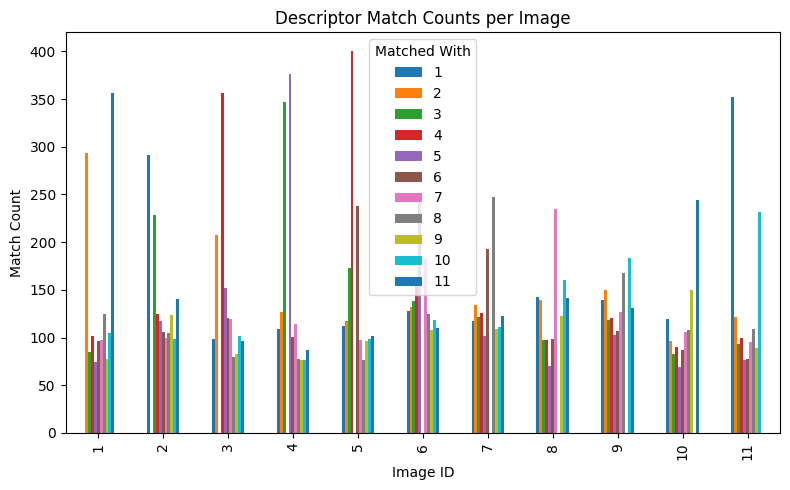

In [27]:
# Pivot the data so each "MatchedWith" becomes a column
pivot_df = result.pivot(index='ImgId', columns='MatchedWith', values='Count').fillna(0)

# Plot grouped bars
pivot_df.plot(kind='bar', figsize=(8,5))

plt.title("Descriptor Match Counts per Image")
plt.xlabel("Image ID")
plt.ylabel("Match Count")
plt.legend(title="Matched With")
plt.tight_layout()
plt.show()

In [28]:
top_matches = (
    result
    .sort_values(['ImgId', 'Count'], ascending=[True, False])
    .groupby('ImgId')['MatchedWith']
    .apply(list)
    .to_dict()
)

top_matches

{1: [11, 2, 8, 10, 4, 7, 6, 3, 9, 5],
 2: [1, 3, 11, 4, 9, 5, 6, 8, 7, 10],
 3: [4, 2, 5, 6, 7, 10, 1, 11, 9, 8],
 4: [5, 3, 2, 7, 1, 6, 11, 8, 9, 10],
 5: [4, 6, 3, 2, 1, 11, 10, 7, 9, 8],
 6: [5, 7, 4, 3, 2, 1, 8, 10, 11, 9],
 7: [8, 6, 2, 4, 11, 3, 1, 10, 9, 5],
 8: [7, 10, 1, 11, 2, 9, 6, 3, 4, 5],
 9: [10, 8, 2, 1, 11, 7, 4, 3, 6, 5],
 10: [11, 9, 1, 8, 7, 2, 4, 6, 3, 5],
 11: [1, 10, 2, 8, 4, 7, 3, 9, 6, 5]}

## Determine Matches Between 2 specific Images From matching_df

1. Reduce matching_df to entries containing reference image (ImageID) and has target Image in "Matched_ImgIds" column.
2. Create macth tuple for each row, saying which keypoint from reference is matched to which keypoint in traget.
3. Combine the match tuples from all the rows in the   

In [29]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]","[11, 8, 7, 11]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[690, 684]","[2, 2]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[5041, 3302, 3213]","[11, 7, 7]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[3663, 3450, 2088]","[8, 7, 5]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 5197, 4038, 1502]","[11, 11, 9, 4]"


In [30]:
# image to match / stitch
id1 = 1
id2 = 11

In [33]:
def get_sub_matching_dataframe(id1, id2, matching_df):
    """
    Reduces matching_df to a subset containing features that are matched between 2 specific images. 

    Args:
        id1 (int): what 'ImgId' column should be equal to
        id2 (int): what should be in 'Matched_ImgIds' column
        matching_df (pandas dataframe): 

    Returns:
        pandas dataframe: subset of matching_df
    """
    sub_matching_df = matching_df[
        (matching_df["ImgId"] == id1) &
        (matching_df['Matched_ImgIds'].apply(lambda x: id2 in x))
        ]
    return sub_matching_df

def generate_id_pair(row, id2: int):
    feature_id_img1 = int(row.Index)  # id of feature in reference image 
    matched_ids = np.array(row.Matched_Ids)  # ids of matched feature
    img_ids = np.array(row.Matched_ImgIds)  # ids of images of matched features
    mask = img_ids == id2
    valid_id = matched_ids[mask]
    new_entries = [(feature_id_img1, int(feature_id_img2)) for feature_id_img2 in valid_id]
    return new_entries


def determine_matches_between_image_pair(id1, id2, matching_df):
    sub_matching_df = get_sub_matching_dataframe(id1, id2, matching_df)
    id_matches = [] 
    for row in sub_matching_df.itertuples(index=True):
        id_matches.extend(generate_id_pair(row, id2))
    return id_matches

matched_ids = determine_matches_between_image_pair(id1, id2, matching_df)

In [34]:
matched_ids

[(0, 5073),
 (0, 5189),
 (2, 5041),
 (4, 5075),
 (4, 5197),
 (7, 5370),
 (9, 5011),
 (10, 5177),
 (15, 5037),
 (18, 5018),
 (18, 5099),
 (23, 5133),
 (23, 5275),
 (24, 5125),
 (26, 5319),
 (27, 5042),
 (29, 5056),
 (29, 5464),
 (30, 5043),
 (35, 5023),
 (35, 5176),
 (37, 5042),
 (37, 5130),
 (38, 5104),
 (39, 5038),
 (39, 5112),
 (40, 5033),
 (40, 5096),
 (41, 5101),
 (44, 5046),
 (47, 5072),
 (48, 5001),
 (50, 5045),
 (50, 5124),
 (50, 5058),
 (50, 5086),
 (51, 5016),
 (51, 5329),
 (51, 5261),
 (52, 5101),
 (52, 5142),
 (57, 5063),
 (58, 5461),
 (58, 5033),
 (59, 5039),
 (62, 5027),
 (63, 5312),
 (65, 5031),
 (65, 5162),
 (66, 5036),
 (66, 5451),
 (67, 5130),
 (68, 5277),
 (68, 5238),
 (69, 5234),
 (69, 5371),
 (70, 5142),
 (70, 5024),
 (70, 5300),
 (75, 5050),
 (75, 5096),
 (76, 5125),
 (78, 5272),
 (82, 5490),
 (83, 5166),
 (83, 5309),
 (84, 5096),
 (90, 5077),
 (93, 5209),
 (93, 5206),
 (93, 5118),
 (94, 5096),
 (94, 5238),
 (96, 5088),
 (97, 5447),
 (98, 5041),
 (101, 5105),
 (101

In [35]:
def get_homogrphy(kps, matched_ids):
    src = np.empty((len(matched_ids),2), dtype=np.float32)  # coords of features from reference image 
    dst = np.empty((len(matched_ids),2), dtype=np.float32)  # coords of features from target image 

    for i, id_pair in enumerate(matched_ids):
        kp_id1, kp_id2 = id_pair  # get ids of features 
        kp1, kp2 = kps[kp_id1], kps[kp_id2]  # use ids of features to get their objs
        src[i,0] = kp1.pt[0]  # x coord
        src[i,1] = kp1.pt[1]  # y coord
        dst[i,0] = kp2.pt[0]  # x coord
        dst[i,1] = kp2.pt[1]  # y coord

    H, _ =  cv2.findHomography(dst, src, cv2.RANSAC, 5.0)
    return H  # transfromion to go from target to reference  

H = get_homogrphy(kps, matched_ids)

In [36]:
H

array([[ 1.61444255e+00,  3.20269962e-02, -9.13045677e+02],
       [ 1.96423963e-01,  1.44652167e+00, -2.14042535e+02],
       [ 5.69134303e-04,  4.72145286e-05,  1.00000000e+00]])

In [52]:
img1 = cv2.imread(img_paths[id1-1], cv2.IMREAD_COLOR_RGB)
img2 = cv2.imread(img_paths[id2-1], cv2.IMREAD_COLOR_RGB)

In [53]:


# def stitch_images(img1, img2, H):
#     h1, w1 = img1.shape[:2]
#     h2, w2 = img2.shape[:2]

#     # Get the canvas dimesions
#     pts = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
#     img2_warped = cv2.warpPerspective(img2, H, (w1 + w2, h1))

#     # Place the first image on the canvas
#     img2_warped[0:h1, 0:w1] = img1
#     return img2_warped

# stitched = stitch_images(img1, img2, H)

# # Display inline
# plt.imshow(stitched, cmap="gray")
# plt.axis('off')  # hide axes
# plt.show()

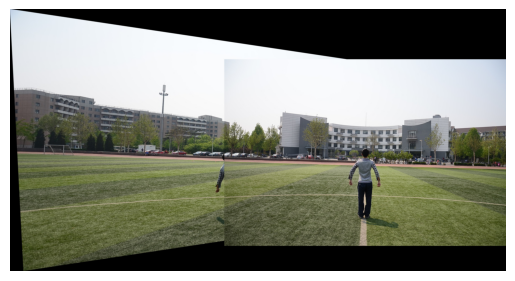

In [54]:
def stitch_images2(img1, img2, H):
    """
    Stitch img2 onto img1 using homography H (img2 -> img1)
    img1 is the base canvas
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Corners of img2
    corners_img2 = np.array([[0,0],[0,h2],[w2,h2],[w2,0]], dtype=np.float32).reshape(-1,1,2)
    # Warp corners into img1's frame using H
    warped_corners = cv2.perspectiveTransform(corners_img2, H)

    # Corners of img1
    corners_img1 = np.array([[0,0],[0,h1],[w1,h1],[w1,0]], dtype=np.float32).reshape(-1,1,2)

    # All corners together to find canvas size
    all_corners = np.concatenate((warped_corners, corners_img1), axis=0)
    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Translation matrix to shift everything into positive coordinates
    translation = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]])

    # Warp img2 into canvas
    result = cv2.warpPerspective(img2, translation @ H, (xmax - xmin, ymax - ymin))
    # Place img1 into canvas
    result[-ymin:h1 - ymin, -xmin:w1 - xmin] = img1

    return result

stitched = stitch_images2(img1, img2, H)

# Display inline
plt.imshow(stitched, cmap="gray")
plt.axis('off')  # hide axes
plt.show()

In [51]:
type(stitched)

numpy.ndarray

In [ ]:
paths = file_utils.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image-stitching/datasets/example-data/myself")
models.Sticth
